# 12c — IPCC Grid-Resolution Formulas

Covers `chap12_grid1` and `chap12_grid2a` through `grid2e`: a global
grid-box-count estimate, and the derivation, visualization, integration,
and tabulation of the IPCC-style horizontal-resolution formula

$$R(\varphi) = \ell_\varphi \sqrt{\Delta\varphi\cdot\Delta\lambda\cdot\cos\varphi},
\qquad \ell_\varphi = \frac{\pi R_{\oplus}}{180}$$

— the physical ground distance (km) spanned by a $\Delta\varphi\times
\Delta\lambda$ degree grid cell at latitude $\varphi$, which shrinks
toward the poles as meridians converge ($\cos\varphi\to0$). `grid2e`
introduces the shared `compute_horizontal_resolution` helper (in the
archive's chapter-12 root, not a numbered exercise) that later
`grid3*` scripts reuse directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate

DATA_DIR = "../../data"

color_blue = "#1f77b4"

plt.rcParams["figure.dpi"] = 100


## 1. Global grid-box-count estimate (`chap12_grid1`)

A back-of-the-envelope estimate of how many grid boxes (and how much data)
a climate model produces: Earth's surface area divided into $100\times100$
km boxes, inflated by a factor of $L=10$ (vertical levels), fixed at a
round $510{,}000$ boxes times $7$ variables, times $24$ hourly time steps
per day, times $100$ years of daily data.

In [2]:
R = 6371.0  # km
A = 4 * np.pi * R ** 2
print(f"A = {A:,.0f} km^2")

h = 100.0
n_boxes = A / (h * h)
print(f"# boxes = {n_boxes:,.0f}")

L = 10
n_boxes = L * n_boxes
print(f"# boxes = {n_boxes:,.0f}")

n_boxes = 510_000
n_var = 7
n_boxes = n_var * n_boxes
print(f"# boxes = {n_boxes:,.0f}")

dt = 24
n_boxes = dt * n_boxes
print(f"# boxes / day = {n_boxes:,.0f}")

n_year = 100
n_boxes = n_year * 365 * n_boxes
print(f"# boxes / 100 years = {n_boxes:,.0f}")


A = 510,064,472 km^2
# boxes = 51,006
# boxes = 510,064
# boxes = 3,570,000
# boxes / day = 85,680,000
# boxes / 100 years = 3,127,320,000,000


## 2. The resolution formula, evaluated pointwise (`chap12_grid2a`)

$\ell_\varphi$ for the WGS84 semi-major/semi-minor axes and for the mean
Earth radius $R=6371$ km, then the shrinking east-west distance
$\ell_\varphi\cos\varphi$ and the full resolution formula $R(\varphi)$
(for $\Delta\varphi=\Delta\lambda=10°$) at five representative
latitudes.

In [3]:
R_axes = np.array([6378.137, 6356.752])
length_phi_axes = np.pi * R_axes / 180
print("length_phi (WGS84 a, b):", np.round(length_phi_axes, 2))

R = 6371.0
length_phi = np.pi * R / 180
print(f"length_phi (R=6371 km) = {length_phi:.1f} km/deg")

phi_deg = np.array([0, 30, 45, 60, 90])
phi = np.radians(phi_deg)
length_delta = length_phi * np.cos(phi)
display(pd.Series(np.round(length_delta, 1), index=[f"{d}\u00b0" for d in phi_deg], name="length_phi*cos(phi) (km)"))

delta_phi = delta_lambda = 10.0
R_res = length_phi * np.sqrt(delta_phi * delta_lambda * np.cos(phi))
display(pd.Series(np.round(R_res, 0), index=[f"{d}\u00b0" for d in phi_deg], name="R(phi), 10x10 deg grid (km)"))


length_phi (WGS84 a, b): [111.32 110.95]
length_phi (R=6371 km) = 111.2 km/deg


0°     111.2
30°     96.3
45°     78.6
60°     55.6
90°      0.0
Name: length_phi*cos(phi) (km), dtype: float64

0°     1112.0
30°    1035.0
45°     935.0
60°     786.0
90°       0.0
Name: R(phi), 10x10 deg grid (km), dtype: float64

## 3. Resolution vs. latitude, continuously (`chap12_grid2b`)

The same $10°\times10°$-grid resolution formula plotted continuously from
the equator to the pole, with extra density near $90°$ where the curve's
behavior changes fastest.

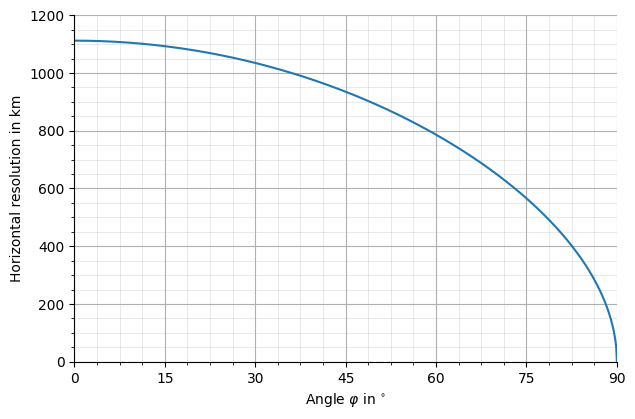

In [4]:
length_phi = np.pi * R / 180
phi_deg = np.concatenate([np.arange(0, 0.9 * 90, 0.2), np.arange(0.9 * 90, 90 + 0.1, 0.1)])
phi = np.radians(phi_deg)
delta_phi = delta_lambda = 10.0
R_curve = length_phi * np.sqrt(delta_phi * delta_lambda * np.cos(phi))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(phi_deg, R_curve, "-", color=color_blue, linewidth=1.5)
ax.grid(True, which="major")
ax.grid(True, which="minor", linewidth=0.4, alpha=0.5)
ax.minorticks_on()
ax.set_xlabel(r"Angle $\varphi$ in $^{\circ}$")
ax.set_ylabel("Horizontal resolution in km")
ax.set_xlim(0, 90)
ax.set_xticks(range(0, 91, 15))
ax.set_ylim(0, 1200)
ax.set_yticks(range(0, 1201, 200))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()


## 4. Latitude-averaged resolution, by integration (`chap12_grid2c`)

The mean value of $\sqrt{\cos\varphi}$ (dimensionless), and of the full
resolution formula at $\Delta\varphi=1°$, $10°$, and $1.1°$, each averaged
over $\varphi\in[0,\pi/2]$ via $\frac{1}{\pi/2}\int_0^{\pi/2}(\cdot)\,d\varphi$
— quadrature standing in for MATLAB's `integral`.

In [5]:
length_phi = np.pi * R / 180
delta_phi = delta_lambda = 1.0
int1 = integrate.quad(lambda phi: np.sqrt(delta_phi * delta_lambda * np.cos(phi)), 0, np.pi / 2)[0] / (np.pi / 2)
int2 = integrate.quad(lambda phi: length_phi * np.sqrt(delta_phi * delta_lambda * np.cos(phi)), 0, np.pi / 2)[0] / (np.pi / 2)

delta_phi = delta_lambda = 10.0
int3 = integrate.quad(lambda phi: length_phi * np.sqrt(delta_phi * delta_lambda * np.cos(phi)), 0, np.pi / 2)[0] / (np.pi / 2)

print(f"[int1, int2, int3] = [{int1:.4f}, {int2:.4f}, {int3:.4f}]")

delta_phi = delta_lambda = 1.1
int4 = integrate.quad(lambda phi: length_phi * np.sqrt(delta_phi * delta_lambda * np.cos(phi)), 0, np.pi / 2)[0] / (np.pi / 2)
print(f"int4 = {int4:.4f}")


[int1, int2, int3] = [0.7628, 84.8150, 848.1502]
int4 = 93.2965


## 5. Resolution table across grid sizes (`chap12_grid2d`)

$R(\varphi)$ at the equator and at $45°$, plus the average-resolution
shortcut $R_{avg}=0.7628\,\ell_\varphi\,\Delta\varphi$ (the $\sqrt{\cos}$
factor's own latitude-average from `grid2c`'s $\Delta\varphi=1°$
integral folded into a single constant), for a descending sequence of
grid resolutions typical of climate-model generations (a coarse $5.6°$
FAR-era grid down to a fine $0.375°$ AR6-era grid).

In [6]:
length_phi = np.pi * R / 180
print(f"length_phi = {length_phi:.1f} km/deg")

phi_deg = np.array([0, 45])
phi = np.radians(phi_deg)
delta_phi = np.array([5.6, 4.0, 2.8, 2.5, 1.9, 1.4, 1.1, 0.75, 0.375])
delta_lambda = delta_phi

R_table = length_phi * np.sqrt(np.outer(delta_phi * delta_lambda, np.ones_like(phi)) * np.cos(phi))
R_avg = 0.7628 * length_phi * np.sqrt(delta_phi * delta_lambda)

result = pd.DataFrame(R_table, index=delta_phi, columns=[f"R(phi={d}deg)" for d in phi_deg])
result["R_avg"] = R_avg
result.index.name = "delta_phi=delta_lambda (deg)"
display(result.round(0))


length_phi = 111.2 km/deg


,R(phi=0deg),R(phi=45deg),R_avg
delta_phi=delta_lambda (deg),,,
5.600,623.0,524.0,475.0
4.000,445.0,374.0,339.0
2.800,311.0,262.0,237.0
2.500,278.0,234.0,212.0
1.900,211.0,178.0,161.0
1.400,156.0,131.0,119.0
1.100,122.0,103.0,93.0
0.750,83.0,70.0,64.0
0.375,42.0,35.0,32.0


## 6. Same table via `compute_horizontal_resolution` (`chap12_grid2e`)

Repeats `grid2d`'s table (with a $10°$ resolution added at the coarse end)
through the shared helper `compute_horizontal_resolution`, which hardcodes
$\ell_\varphi=111.2$ km/deg (i.e. $R=6371$ km, matching this notebook's
value to 1 decimal place) and evaluates $R_0=R(\varphi{=}0)$,
$R_{45}=R(\varphi{=}45°)$, and $R_{avg}=0.7628\,R_0$ directly.

In [7]:
def compute_horizontal_resolution(delta_phi, delta_lambda):
    # Port of compute_horizontal_resolution.m (shared helper, chapter-12 root)
    length_phi = 111.2
    R_0 = length_phi * np.sqrt(delta_phi * delta_lambda * np.cos(0.0))
    R_45 = length_phi * np.sqrt(delta_phi * delta_lambda * np.cos(np.pi / 4))
    R_avg = 0.7628 * R_0
    return R_0, R_45, R_avg


delta_phi = np.array([10, 5.6, 4.0, 2.8, 2.5, 1.9, 1.4, 1.1, 0.75, 0.375])
delta_lambda = delta_phi

R_0, R_45, R_avg = compute_horizontal_resolution(delta_phi, delta_lambda)
result2 = pd.DataFrame({"R_0 (phi=0)": R_0, "R_45 (phi=45deg)": R_45, "R_avg": R_avg}, index=delta_phi)
result2.index.name = "delta_phi=delta_lambda (deg)"
display(result2.round(0))


,R_0 (phi=0),R_45 (phi=45deg),R_avg
delta_phi=delta_lambda (deg),,,
10.000,1112.0,935.0,848.0
5.600,623.0,524.0,475.0
4.000,445.0,374.0,339.0
2.800,311.0,262.0,238.0
2.500,278.0,234.0,212.0
1.900,211.0,178.0,161.0
1.400,156.0,131.0,119.0
1.100,122.0,103.0,93.0
0.750,83.0,70.0,64.0
